# Quantum-enhanced Markov chain Monte Carlo (MCMC) for constrained optimization, run on a QCSC

In this notebook, we lay out the high-level pipeline for using quantum-enhanced MCMC for a constrained optimization task, intended to be run on a QCSC.

The parallel tempering set-up will look as follows:

- **Step 1: Map to quantum problem**
    - Initialize our problem's Hamiltonian
    - All quantum circuits to be sampled have the same structure up to parametrization
- **Step 2: Optimize the problem**
    - Transpile the circuit for hardware
- **Step 3: Execute experiments and Step 4: Post-process results**
    - In the first instance, we will run on a mock setup: using simulated quantum hardware and dummy or small-scale classical hardware
    - We run many replica experiments in parallel each at different temperatures, allowing them to exchange information between replicas at different intervals

## Step 1: Map to quantum problem

### Set up a model Hamiltonian for applying the stable set problem to a 110 node graph instance

In [1]:
# (C) Copyright IBM 2026.
#
# Any modifications or derivative works of this code must retain this
# copyright notice, and modified files need to carry a notice indicating
# that they have been altered from the originals.

from typing import Literal

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qiskit import transpile

from qeco.stable_set import (
    circuit_construction,
    construct_warm_start_circuit,
    run_experiment,
    stable_set_value,
)
from qeco.utils.graph_utils import (
    load_graph,
    swap_strategy_simplify,
)
from qeco.utils.post_process_utils import (
    boost_samples,
    run_metropolis_hastings,
)
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import (
    SwapStrategy,
)
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_optimization.applications import StableSet
from qiskit_optimization.converters import QuadraticProgramToQubo

In [2]:
service = QiskitRuntimeService(name="stfc-qeco-us")
backend = service.backend("ibm_kingston")

print(f"Backend selected is {backend}")

management.get:WARNING:2026-03-08 11:48:59,546: Loading saved account: stfc-qeco-us


Backend selected is <IBMBackend('ibm_kingston')>


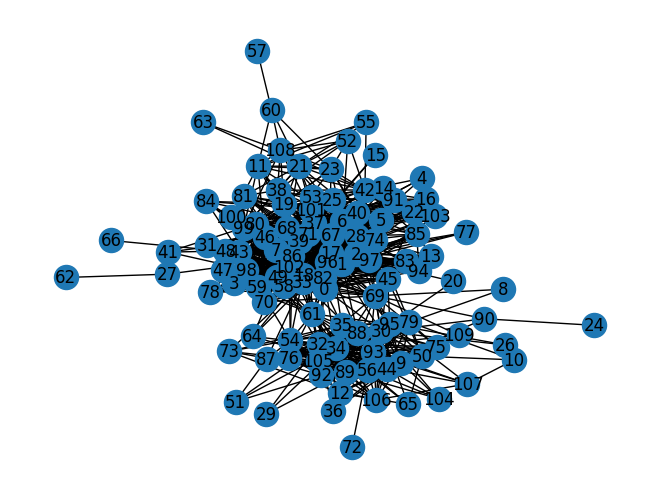

In [3]:
graph_filename = "./data/aves-songbird-social.gph"

graph = load_graph(graph_filename)
nx.draw_kamada_kawai(graph, node_size=300, with_labels=True)

In [4]:
swap_strat = SwapStrategy.from_line(range(graph.order()))
edge_coloring = {(idx, idx + 1): (idx + 1) % 2 for idx in range(graph.order())}

## Step 2: Optimize for target hardware

### We are now in a position to translate from QUBO > Ising Hamiltonian > QAOA circuit

For which the conversion is somewhat trivial and has been omitted from this notebook. Please see function definitions for details.

In [5]:
# create stable set problem for graph and subgraphs
instance = StableSet(graph)
# represent optimization problem as quadratic program
quadratic_program = instance.to_quadratic_program()

In [6]:
# create a sensible QAOA circuit used as a start-point for some of these benchmarks, using a subgraph

subgraphs = swap_strategy_simplify(swap_strat, graph)
subgraph_6_SWAP = subgraphs[6]

# create stable set problem for graph and subgraphs
instance_6_SWAP = StableSet(subgraph_6_SWAP)
# represent optimization problem as quadratic program
quadratic_program_6_SWAP = instance_6_SWAP.to_quadratic_program()

penalty_6_SWAP = 0.893

# derive QUBO representations for stable set problem
qubo_6_SWAP = QuadraticProgramToQubo(penalty=penalty_6_SWAP).convert(
    quadratic_program_6_SWAP
)

op_6_SWAP, _ = qubo_6_SWAP.to_ising()

# calculate the total number of Z operators in each term of Ising ham
# select terms == 1 Z operator (single-qubit / linear interactions)
singles= op_6_SWAP[op_6_SWAP.paulis.z.sum(axis=-1) == 1]
# select terms == 2 Z operator (two-qubit / quadratic interactions)
doubles = op_6_SWAP[op_6_SWAP.paulis.z.sum(axis=-1) == 2]

params = [
    0.4020205218198449,
    0.4020205218198449,
    0.9538688915557414,
    0.9538688915557414,
]  ## 6 SWAP layers

circuit = circuit_construction(
    singles,
    doubles,
    params,
    backend,
    swap_strat,
    edge_coloring,
    layers=2,  # 2 layer QAOA
)

#### Let's print some circuit data for the full graph circuit

In [7]:
def print_circuit_info(circ, two_qubit_gate="cz"):
    n2q = circ.count_ops().get(two_qubit_gate, 0)
    depth = circ.depth(lambda instr: len(instr.qubits) > 1)
    print(
        f"The circuit {circ.name} has {n2q} two-qubit gates and a two-qubit gate depth of {depth}."
    )


print_circuit_info(transpile(circuit["backend"], backend, optimization_level=3))

# FULL GRAPH
# The circuit circuit-2334-2341 has 39450 two-qubit gates and a two-qubit gate depth of 696.

The circuit circuit-428-435 has 1578 two-qubit gates and a two-qubit gate depth of 42.


In [8]:
backend_properties = backend.properties()


def get_gate_fidelity(gate, qubits):
    try:
        gate_error = backend_properties.gate_error(gate, qubits)
        if gate_error == 1.0:
            return 1.0
        else:
            return 1 - gate_error
    except:
        return 1.0


def get_measurement_fidelity(qubit):
    try:
        readout_error = backend_properties.readout_error(qubit)
        return 1 - readout_error
    except:
        return 1.0


total_fidelity = 1.0
gate_names = ["delay", "rz", "sx", "cz", "x"]

for instruction in circuit["backend"].data:
    instr = instruction.operation
    qubits = instruction.qubits
    clbits = instruction.clbits
    gate_name = instr.name
    qubit_indices = [q._index for q in qubits]

    if gate_name == "measure":
        # compute measurement fidelity
        for q in qubit_indices:
            total_fidelity *= get_measurement_fidelity(q)
    elif gate_name in gate_names:
        total_fidelity *= get_gate_fidelity(gate_name, tuple(qubit_indices))
    else:
        pass

print(f"Estimated circuit fidelity: {total_fidelity:.50f}")

Estimated circuit fidelity: 0.00005410299809743319168721040202107985805923817679


#### We can now compute the sampling overhead used in our later experiments from this estimation of circuit fidelity

See this paper for reference: https://arxiv.org/abs/2312.00733

In [9]:
sampling_overhead = 1 / total_fidelity
print(f"Sampling overhead: {sampling_overhead:.6f}")

Sampling overhead: 18483.264055


## Step 3 & 4: Execute on quantum hardware and post-process

 #### First, calculate a baseline with CPLEX

In [10]:
target_cv = -42

First lets run the program for qMCMC circuits, as we do on hardware

In [11]:
import math
import random

from src.qeco.stable_set import (
    construct_init_state,
    construct_mixer,
    soften_bitstring,
)
from src.qeco.utils.post_process_utils import run_parallel_tempering_swap_accept


def compute_best_solution(proposed_solutions, graph, penalty=1.1, filter=0.001):
    """Evaluate lowest energy solutions (best 10%) from all proposals then randomly sample one of these."""
    energies = []
    for proposal, count in proposed_solutions.items():
        proposed_s_array = np.array([int(bit) for bit in proposal])
        E_out = stable_set_value(proposed_s_array[::-1], graph, penalty)
        energies.append((proposal, int(count), E_out))

    # sort by energy (lower is better)
    energies.sort(key=lambda t: t[2])

    # filter top 10% (at least 1)
    n = len(energies)
    k = max(1, math.ceil(filter * n))
    cutoff_energy = energies[k - 1][2]
    top_subset = [t for t in energies if t[2] <= cutoff_energy]

    # sample one uniformly from the top subset
    chosen_proposal, chosen_count, chosen_energy = random.choice(top_subset)

    return {chosen_proposal: chosen_count}, chosen_energy


def _qmcmc_parallel_tempering_simulation(
    circuits: list,
    params: list,
    graph,
    backend=None,
    max_steps: int = 100,
    burn_in: int = 10,
    temps: list[float] = [],
    epsilons_init: list[float] = [],
    epsilons_mixer: list[float] = [],
    target_cv: float = target_cv,
    stop_threshold: int = 5,
    gamma: int = 5,
    boosting: Literal["complete", "partial"] | None = None,
    shots: int = 1,
    session=None,
):
    """Parallel tempering."""
    # track boosted signal distributions over Iterations
    num_replicas = len(temps)
    accepted_solutions = [None] * num_replicas
    obj_values = [float("inf")] * num_replicas
    accepted_obj_values = [[] for _ in range(num_replicas)]

    # keep counters (counts, not rates) and later normalize to produce rates
    swap_accepts = [0] * (num_replicas - 1)
    swap_attempts = [0] * (num_replicas - 1)
    local_accepts = [0] * num_replicas
    local_attempts = [0] * num_replicas
    consecutive_hits = [0] * num_replicas
    converged_chain = None
    # accepted_solution = None
    cumulative_step = 0

    if backend is not None:
        session = Session(backend=backend)

    while cumulative_step < max_steps:
        converged_chain = None  # track if any chain / replica converged
        for step in range(gamma):
            for i in range(num_replicas):
                T = temps[i]
                epsilon_init = epsilons_init[i]
                epsilon_mixer = epsilons_mixer[i]
                circ_i = circuits[i]
                params_i = params[i]

                # print(
                #     f"Replica {i} | Temperature: {T:.3f} | Step {cumulative_step + 1}"
                # )

                if accepted_solutions[i] is not None:
                    prev_solution = accepted_solutions[i] or best_proposed_solution
                    prev_bitstring = next(iter(prev_solution.keys()))
                    # soften bitstring to relaxed values releveant for building init_state and mixer
                    # see ref https://quantum-journal.org/papers/q-2021-06-17-479/pdf/
                    softened_bitstring_init = soften_bitstring(
                        prev_bitstring, epsilon_init
                    )
                    softened_bitstring_mixer = soften_bitstring(
                        prev_bitstring, epsilon_mixer
                    )
                    init_state = construct_init_state(
                        circ_i, softened_bitstring_init
                    )
                    # update mixer in circuit
                    mixer_layer = construct_mixer(
                        circ_i, softened_bitstring_mixer
                    )
                    warm_started_circuit = construct_warm_start_circuit(
                        init_state, mixer_layer, circ_i, params_i, backend
                    )
                    circ_i = warm_started_circuit

                solution = run_experiment(
                    circ_i,
                    shots=shots,
                    backend=None,
                    session=session,
                )

                if boosting in ("complete", "partial"):
                    boosted_solution, _ = boost_samples(solution, graph, boosting)
                else:
                    boosted_solution = solution

                best_proposed_solution, best_proposed_obj_value = compute_best_solution(
                    dict(boosted_solution), graph, penalty=1.1
                )
                local_attempts[i] += 1

                if accepted_solutions[i] is None and cumulative_step == 0:
                    accepted_solution = best_proposed_solution
                    accepted_obj_value = best_proposed_obj_value
                else:
                    # accept reject MH step
                    prev_solution = accepted_solutions[i] or best_proposed_solution
                    prev_bitstring = next(iter(prev_solution.keys()))
                    new_solution = run_metropolis_hastings(
                        prev_solution,
                        best_proposed_solution,
                        graph,
                        T=T,
                    )
                    new_bitstring = next(iter(new_solution.keys()))
                    if new_bitstring != prev_bitstring:
                        local_accepts[i] += 1
                    accepted_solution = new_solution
                    accepted_obj_value = stable_set_value(
                        np.array([int(b) for b in new_bitstring[::-1]]), graph
                    )

                accepted_solutions[i] = accepted_solution
                obj_values[i] = accepted_obj_value
                accepted_obj_values[i].append(accepted_obj_value)

                consecutive_hits[i] = consecutive_hits[i] + 1 if obj_values[i] == target_cv else 0
                if consecutive_hits[i] >= stop_threshold:
                    converged_chain = i
                    # print(f"Replica {i} converged after {cumulative_step + 1} steps.")

                consecutive_hits[i] = (
                    consecutive_hits[i] + 1 if obj_values[i] == target_cv else 0
                )

            cumulative_step += 1

            # break out if any replica converged
            if converged_chain is not None or cumulative_step >= max_steps:
                break

        # break outermost loop if convergence detected
        if converged_chain is not None or cumulative_step >= max_steps:
            break

        # swaps: alternate between even and odd pairs
        if cumulative_step > burn_in and cumulative_step % gamma == 0:
            swap_phase = (
                cumulative_step // gamma
            ) % 2  # alternates between 0, 1, 0, 1...
            for i in range(swap_phase, num_replicas - 1, 2):
                solution_i, solution_j = (
                    accepted_solutions[i],
                    accepted_solutions[i + 1],
                )
                temp_i, temp_j = temps[i], temps[i + 1]

                if solution_i is None or solution_j is None:
                    continue

                swap_attempts[i] += 1
                swap_accepted = run_parallel_tempering_swap_accept(
                    solution_i, solution_j, temp_i, temp_j, graph
                )

                if swap_accepted:
                    accepted_solutions[i], accepted_solutions[i + 1] = (
                        accepted_solutions[i + 1],
                        accepted_solutions[i],
                    )
                    obj_values[i], obj_values[i + 1] = (
                        obj_values[i + 1],
                        obj_values[i],
                    )
                    swap_accepts[i] += 1
                    # print(
                    #     f"Swap accepted between replicas {i} (T={temp_i:.3f}) and {i+1} (T={temp_j:.3f})."
                    # )
                else:
                    # print(
                    #     f"Swap rejected between replicas {i} (T={temp_i:.3f}) and {i+1} (T={temp_j:.3f})."
                    # )
                    continue

    if backend is not None:
        session.close()

    return accepted_obj_values

### Define experiment parameters - temperatures, numbers of replicas etc.

In [12]:
T_low = 0.01
temps = [T_low, T_low + 0.1, T_low + 0.2, T_low + 0.5, T_low + 1]
epsilons = [0.0001, 0.001, 0.002, 0.005, 0.01]
# epsilons = [0.01, 0.01, 0.01, 0.01, 0.01]
num_replicas = len(temps)

qmcmc_circuits = [
    circuit,
    circuit,
    circuit,
    circuit,
    circuit,
]
qmcmc_circuit_params = [
    params,
    params,
    params,
    params,
    params,
]

In [ ]:
from tqdm.notebook import tqdm


# remove and reset when done
def run_experiment(circuit, shots=1, backend=None, session=None):
    trunc_thr = 1e-8
    sim = AerSimulator(
        method="matrix_product_state",
        matrix_product_state_truncation_threshold=trunc_thr,
    )
    result = sim.run(circuit["circuit_to_sample"], shots=shots).result()
    counts = result.get_counts(0)
    return counts

In [14]:
accepted_obj_values = _qmcmc_parallel_tempering_simulation(
    qmcmc_circuits,
    qmcmc_circuit_params,
    graph,
    # simulation
    backend=None,
    max_steps=1000,
    burn_in=0,
    temps=temps,
    epsilons_init=epsilons,
    epsilons_mixer=epsilons,
    target_cv=target_cv,
    shots=int(10 * sampling_overhead),
)

Accepted solution:  00000000010000001001000000000000010100000000000001010000011011000000000000100100101101000001010001001100000010 E_out:  23.800000000000004
Accepted solution:  00000000010000101100010000000000000010100000001111010100011100010010000101000001100001001100000000000100100010 E_out:  33.00000000000001
Accepted solution:  01100100001010000001010000001000111011000001001101001000011100000010011001001000101001000101010010000100011010 E_out:  12.300000000000004
Accepted solution:  10010010000001000010000001000000001010001001001010011100010000000010000100110100101101001100001100110000011100 E_out:  19.700000000000003
Accepted solution:  01000010000011010101001000010001110010000001000100001001001000010100101000000010101001000000101001000100000000 E_out:  26.200000000000003
Accepted solution:  00000000010000001001000000000000000100000000000001010000011011000000000000100000101101000001010001001100000010 E_out:  14.8
Accepted solution:  00000000010000101100000000000000000010100000001

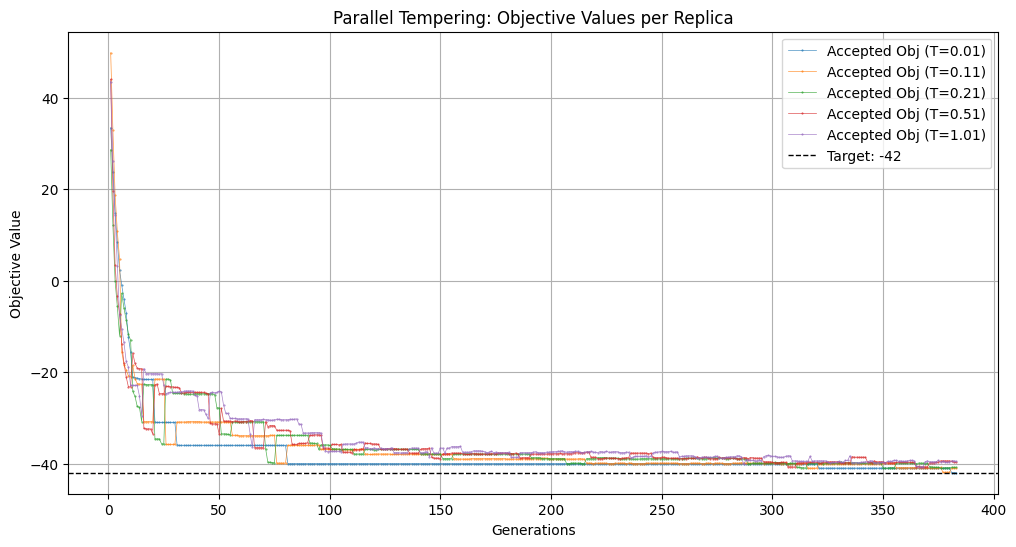

In [16]:
plt.figure(figsize=(12, 6))

for i in range(num_replicas):
    x = np.arange(1, len(accepted_obj_values[i]) + 1)
    plt.plot(
        x,
        accepted_obj_values[i],
        marker="o",
        linestyle="-",
        markersize=0.5,
        linewidth=0.5,
        label=f"Accepted Obj (T={temps[i]:.2f})",
        alpha=0.8,
    )

plt.axhline(
    y=target_cv,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Target: {target_cv}",
)
plt.xlabel("Generations")
plt.ylabel("Objective Value")
plt.title("Parallel Tempering: Objective Values per Replica")
plt.legend(loc="best")
plt.grid(True)
plt.show()